# Scenario-Based Sensitivity Analysis
Following the topological network assessment, we expanded the scope to evaluate city-wide vulnerability. Instead of relying on generic sea-level data, the model employs a Static Inundation Model with a localized hydraulic baseline. This baseline was derived from the 5th percentile of the city's terrain elevation to accurately approximate the riverbed level.

The simulation projects four progressive scenarios by incrementally raising this baseline (+1m, +3m, +5m). To ensure precision, a spatial exclusion mask was applied to filter out permanent water bodies (such as the northern mudflats), ensuring that impact metrics reflect only newly inundated urban areas.

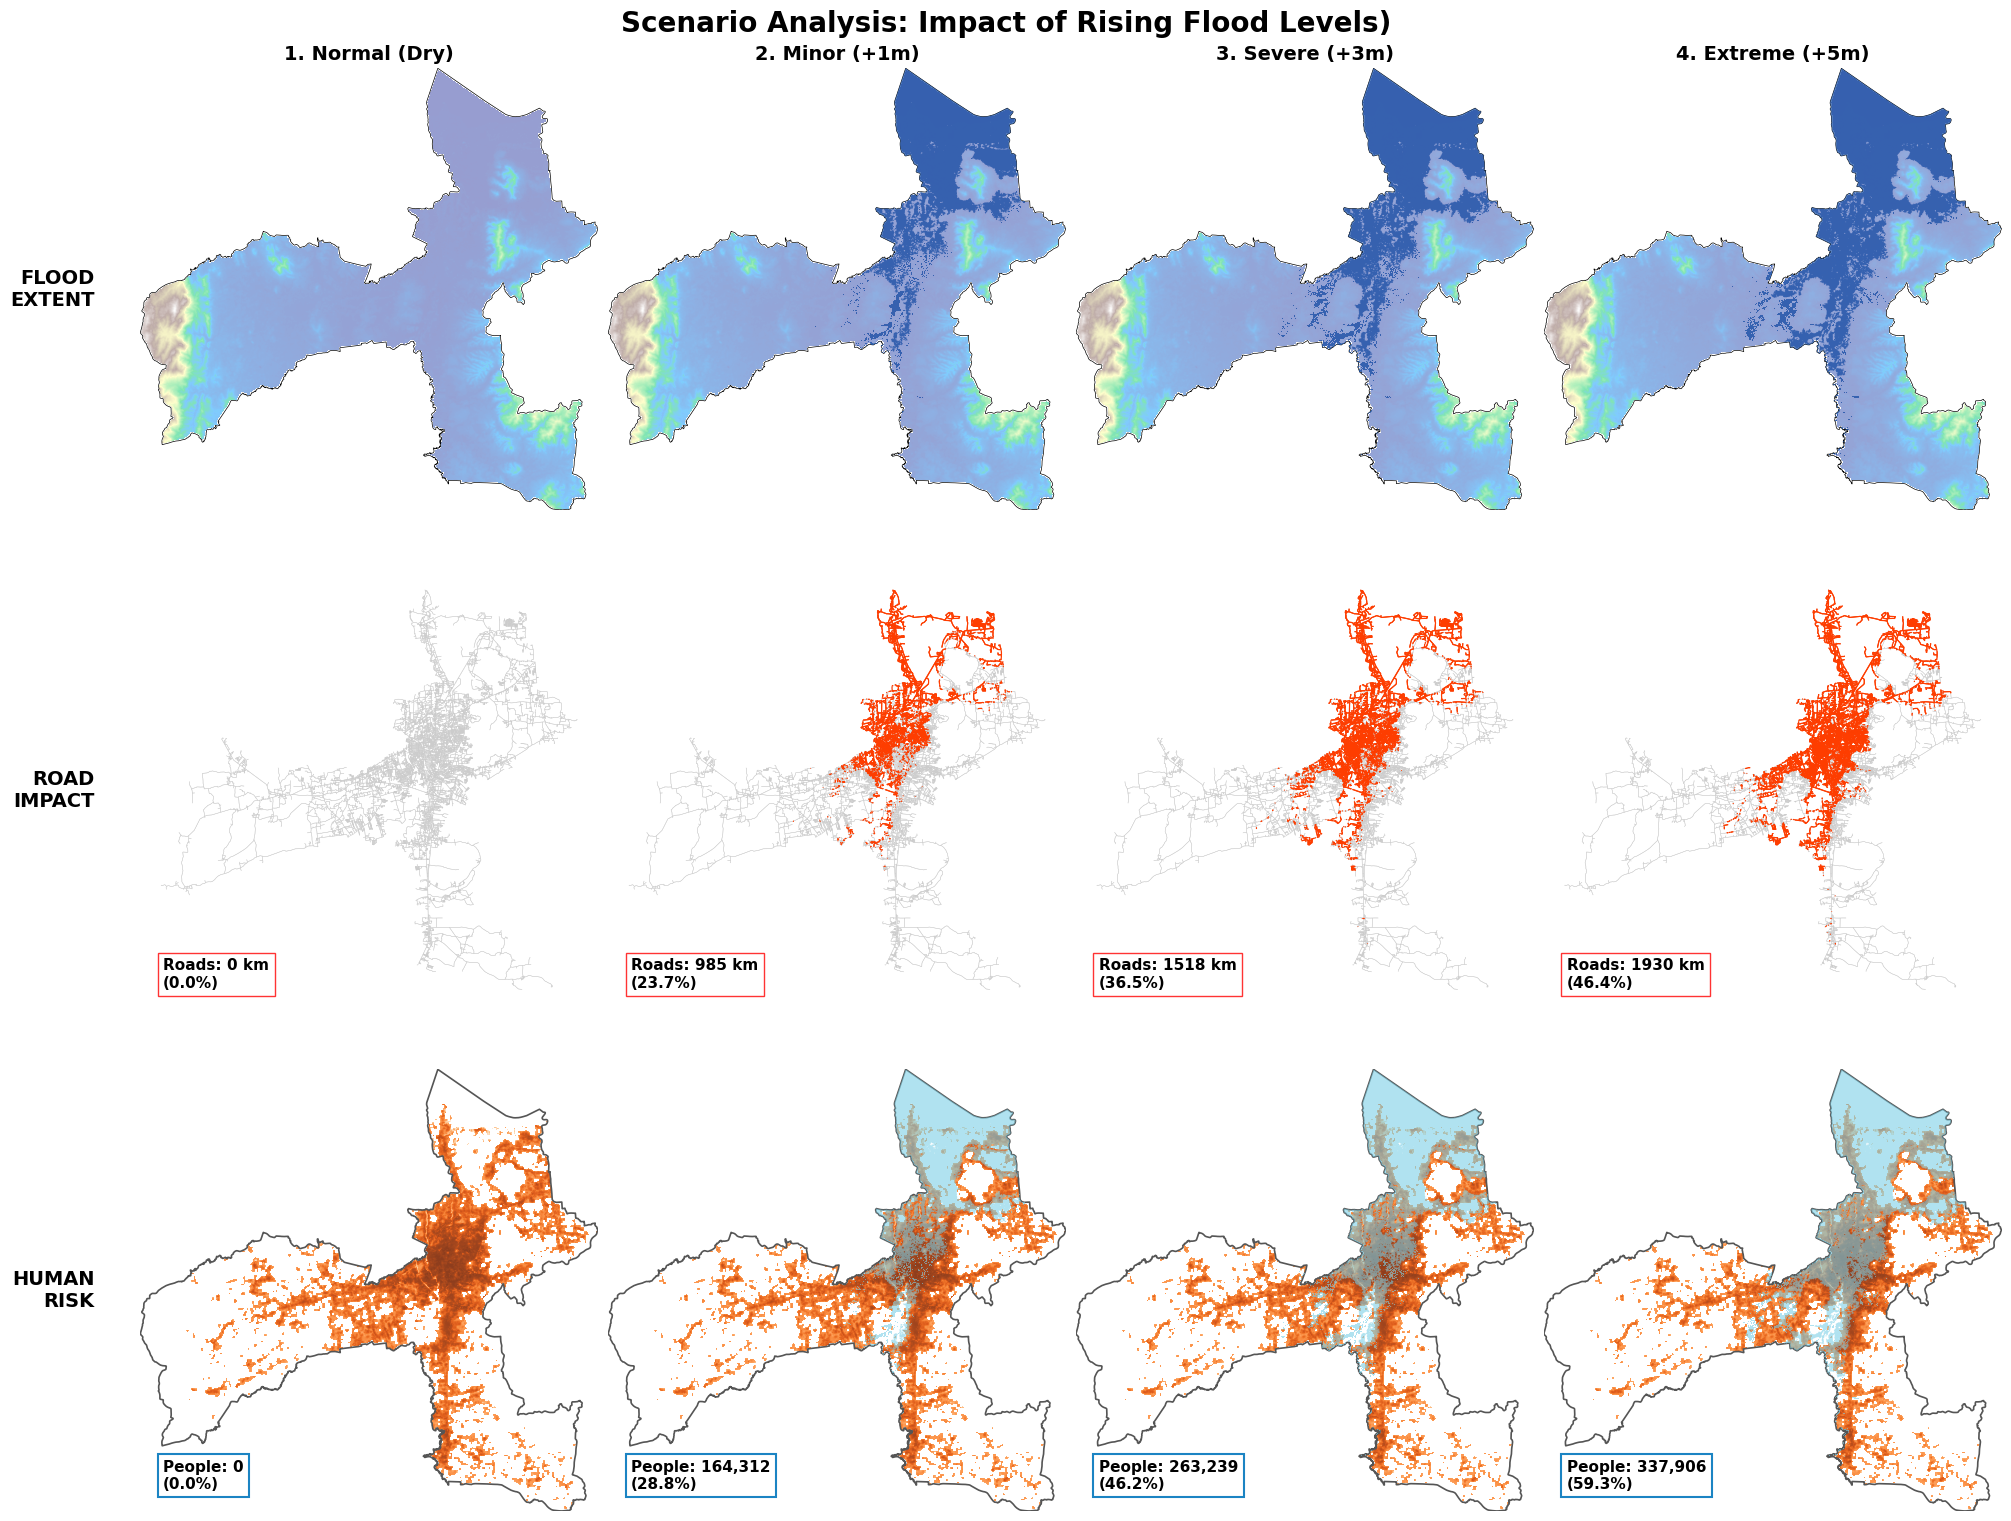

In [16]:
import matplotlib.pyplot as plt
import geopandas as gpd
import rasterio
from rasterio.mask import mask
from rasterio import features
import numpy as np
import osmnx as ox
from shapely.geometry import shape, box
from matplotlib.colors import LogNorm

dem_path = "data/hat_yai_dem_filled.tif" 
pop_path = "data/tha_pop_2025_CN_100m_R2024B_v1.tif"
hat_yai_city = ox.geocode_to_gdf("Hat Yai, Songkhla, Thailand")

city_wgs84 = hat_yai_city.to_crs(epsg=4326)

# Calculation Mask

lake_box = box(100.44, 7.08, 100.65, 7.25) 
lake_gdf = gpd.GeoDataFrame(geometry=[lake_box], crs=4326)

city_calc_area = gpd.overlay(city_wgs84, lake_gdf, how='difference')
# -----------------------------------------------------------

if 'G_proj' not in globals():
    G = ox.graph_from_place("Hat Yai, Songkhla, Thailand", network_type='drive')
    G_proj = ox.project_graph(G)

roads_utm = ox.graph_to_gdfs(G_proj, nodes=False)
roads_wgs84 = roads_utm.to_crs(epsg=4326)

roads_calc_utm = gpd.clip(roads_utm, city_calc_area.to_crs(32647))
total_road_len = roads_calc_utm.length.sum() / 1000  # km


river_bed_level = 0
with rasterio.open(dem_path) as src_dem:
    out_dem, _ = mask(src_dem, city_calc_area.geometry, crop=True)
    dem_arr = out_dem[0]
    valid = dem_arr[dem_arr != src_dem.nodata]
    if len(valid) > 0: river_bed_level = np.nanpercentile(valid, 5)
    else: river_bed_level = 10

# 4 scenarios
scenarios = [
    (None, "1. Normal (Dry)"), 
    (1.0,  "2. Minor (+1m)"),
    (3.0,  "3. Severe (+3m)"),
    (5.0,  "4. Extreme (+5m)")
]

results = []


with rasterio.open(dem_path) as src_dem, rasterio.open(pop_path) as src_pop:
    
    out_pop, pop_trans = mask(src_pop, city_wgs84.geometry, crop=True)
    pop_viz = np.where(out_pop[0] < 0, np.nan, out_pop[0])
    
    out_pop_calc, _ = mask(src_pop, city_calc_area.geometry, crop=True)
    total_pop_calc = np.nansum(np.where(out_pop_calc[0] < 0, 0, out_pop_calc[0]))

    for rise, label in scenarios:
        data = {"label": label, "flood_viz": gpd.GeoDataFrame(), "road_viz": gpd.GeoDataFrame(), 
                "pop_val": 0, "road_val": 0}
        
        if rise is not None:
            target = river_bed_level + rise

            out_dem, out_trans = mask(src_dem, city_wgs84.geometry, crop=True)
            flood_mask = (out_dem[0] <= target) & (out_dem[0] != src_dem.nodata)
            shapes = features.shapes(flood_mask.astype('uint8'), transform=out_trans)
            geoms = [shape(g) for g, v in shapes if v == 1]
            
            if geoms:
                flood_gdf_full = gpd.GeoDataFrame(geometry=geoms, crs=4326)
                data["flood_viz"] = flood_gdf_full

                flood_gdf_calc = gpd.overlay(flood_gdf_full, city_calc_area, how='intersection')
                
                if not flood_gdf_calc.empty:
                    try:
                        out_img, _ = mask(src_pop, flood_gdf_calc.geometry, crop=True)
                        data["pop_val"] = np.nansum(np.where(out_img[0] < 0, 0, out_img[0]))
                    except: pass
                    
                    try:
                        flood_utm_calc = flood_gdf_calc.to_crs(32647)
                        calc_roads = gpd.clip(roads_utm, flood_utm_calc)
                        data["road_val"] = calc_roads.length.sum() / 1000

                        flood_utm_full = flood_gdf_full.to_crs(32647)
                        viz_roads = gpd.clip(roads_utm, flood_utm_full)
                        data["road_viz"] = viz_roads.to_crs(4326)
                    except: pass
        
        results.append(data)

# Visualization
fig, axes = plt.subplots(3, 4, figsize=(20, 15), constrained_layout=True)
fig.patch.set_facecolor('white')


with rasterio.open(dem_path) as src:
    dem_viz_arr, dem_trans = mask(src, city_wgs84.geometry, crop=True)
    dem_viz_arr = np.where(dem_viz_arr[0] == src.nodata, np.nan, dem_viz_arr[0])
    h, w = dem_viz_arr.shape
    extent = [dem_trans[2], dem_trans[2]+w*dem_trans[0], dem_trans[5]+h*dem_trans[4], dem_trans[5]]

for col, data in enumerate(results):
    
    # Row 1: Flood Extent (
    ax1 = axes[0, col]
    ax1.imshow(dem_viz_arr, cmap='terrain', extent=extent, alpha=0.5)
    city_wgs84.plot(ax=ax1, facecolor='none', edgecolor='black', linewidth=0.5)
    
    if not data['flood_viz'].empty:
        data['flood_viz'].plot(ax=ax1, color='#0D47A1', alpha=0.7) # <--- 之前报错就是这里少了括号
    
    ax1.set_title(f"{data['label']}", fontsize=14, fontweight='bold')
    ax1.axis('off')
    if col == 0: ax1.text(-0.1, 0.5, "FLOOD\nEXTENT", transform=ax1.transAxes, 
                          va='center', ha='right', fontsize=14, fontweight='bold')

    # Row 2: Road Impact 
    ax2 = axes[1, col]
    if not roads_wgs84.empty:
        roads_wgs84.plot(ax=ax2, color='#CCCCCC', linewidth=0.3)
    if not data['road_viz'].empty:
        data['road_viz'].plot(ax=ax2, color='#FF3D00', linewidth=0.8)

    pct_road = (data['road_val'] / total_road_len) * 100 if total_road_len > 0 else 0
    ax2.text(0.05, 0.05, f"Roads: {data['road_val']:.0f} km\n({pct_road:.1f}%)", 
             transform=ax2.transAxes, fontsize=11, fontweight='bold', 
             bbox=dict(facecolor='white', alpha=0.8, edgecolor='red'))
    
    ax2.axis('off')
    if col == 0: ax2.text(-0.1, 0.5, "ROAD\nIMPACT", transform=ax2.transAxes, 
                          va='center', ha='right', fontsize=14, fontweight='bold')

    # Row 3: Human Risk 

    ax3 = axes[2, col]
    ax3.set_facecolor('white')
    
    ax3.imshow(pop_viz, cmap=CMAP_POP, norm=LogNorm(), extent=extent, alpha=0.9)

    city_wgs84.plot(ax=ax3, facecolor='none', edgecolor='#555', linewidth=1.2)
    
    if not data['flood_viz'].empty:
        data['flood_viz'].plot(ax=ax3, 
                               color=COLOR_FLOOD,       
                               alpha=0.6,               
                               edgecolor='none')
    
    pct_pop = (data['pop_val'] / total_pop_calc) * 100 if total_pop_calc > 0 else 0
    
    ax3.text(0.05, 0.05, f"People: {int(data['pop_val']):,}\n({pct_pop:.1f}%)", 
             transform=ax3.transAxes, fontsize=11, fontweight='bold',
             bbox=dict(facecolor='white', 
                       alpha=0.9, 
                       edgecolor=COLOR_FLOOD_BORDER,
                       linewidth=1.5))
    
    ax3.axis('off')
    if col == 0: ax3.text(-0.1, 0.5, "HUMAN\nRISK", transform=ax3.transAxes, 
                          va='center', ha='right', fontsize=14, fontweight='bold')

plt.suptitle("Scenario Analysis: Impact of Rising Flood Levels)", 
             fontsize=20, fontweight='bold', y=1.02)

plt.savefig('final_matrix_analysis_fix.png', dpi=300, bbox_inches='tight')
plt.show()



Simulation Parameter: Base Level at 10.0 m

#### The Buffer-Less Reality (+1m Scenario)

The simulation reveals a disturbing lack of hydraulic resilience. The transition from the Baseline to the Minor (+1m) scenario highlights an immediate critical vulnerability. Despite being categorized as "minor," a mere one-meter rise results in disproportionately severe consequences, compromising 23.7% of the road network and impacting 28.8% of the population. This sharp initial spike indicates that Hat Yai’s urban core sits in a topographic depression with virtually no buffer zone.

#### Systemic Collapse (+5m Scenario)

As flood intensity escalates to the Extreme (+5m) level, the impact expands to encompass the majority of the urban fabric. The inundation renders nearly half of the transportation infrastructure (46.4%) inoperable, effectively erasing the city’s grid connectivity. More alarmingly, the analysis projects that 59.3% of the population (approx. 337,906 residents) would be located directly within hazardous zones. This trajectory demonstrates that risk does not scale linearly but accelerates, threatening the city's viability as a habitable regional hub.